# Karma visualization — pt 2: karma vs affiliation

A follow-up to `karma_viz.ipynb`. The question here is whether the karma layer
finds *themes* among the top-100 characters that the affiliation (social)
network does not.

It puts the **same top-100 characters** under two edge sets, side by side:

* **left — karma graph:** an edge joins two of the top 100 when they hold a
  strong feeling about each other (`|score − 5| ≥ 3`). Red is hostility,
  green warmth. The layout pulls characters together by *sentiment*.
* **right — affiliation graph:** the social graph induced on exactly the same
  characters (an edge iff one lists the other under `affiliated`). The layout
  pulls characters together by *shared storyline*.

Both panels colour nodes by **majority house** — the allegiance with the
largest *global* membership (the rule the social affiliation graph uses), not
`karma_viz`'s first-listed rule — and share the website-aligned palette, so a
character keeps one colour across both panels and the two structures can be
compared directly.

The setup cells below reproduce `karma_viz.ipynb` so this notebook runs
standalone; run it top to bottom.

In [32]:
from collections import Counter
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
import numpy as np
import pandas as pd


## Load and validate data

Same loader as `karma_viz.ipynb`: read the karma edge list, build the directed graph `DG`, and define the website-aligned house palette.

In [33]:
from pathlib import Path

# BASE_DIR = the repo root. Resolves correctly whether Jupyter is launched from the
# repo root, from Karma/, or from one level above the repo.
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'csvs').exists() and (BASE_DIR / 'CompSciProject' / 'csvs').exists():
    BASE_DIR = BASE_DIR / 'CompSciProject'
if not (BASE_DIR / 'csvs').exists() and (BASE_DIR.parent / 'csvs').exists():
    BASE_DIR = BASE_DIR.parent

karma = pd.read_csv(BASE_DIR / 'csvs' / 'karma_edges_v3.csv')
karma['karma_score'] = pd.to_numeric(karma['karma_score'], errors='coerce')
karma = karma.dropna(subset=['karma_score'])

df = pd.read_csv(BASE_DIR / 'csvs' / 'characters_enriched_v3.csv').fillna('')
valid_ids = set(df['ID'])
name_by_id = dict(zip(df['ID'], df['name']))
primary_house = {
    row['ID']: (row['allegiance'].split(';')[0].strip() if row['allegiance'] else '')
    for _, row in df.iterrows()
}

before = len(karma)
karma = karma[karma['source_id'].isin(valid_ids) & karma['target_id'].isin(valid_ids)]
print(f'Karma edges: {len(karma):,} (dropped {before - len(karma)} with unknown source/target)')

DG = nx.DiGraph()
for _, row in karma.iterrows():
    DG.add_edge(row['source_id'], row['target_id'], score=float(row['karma_score']))
for n in DG.nodes():
    DG.nodes[n]['house'] = primary_house.get(n, '')

print(f'Directed graph: {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges')


Karma edges: 5,159 (dropped 0 with unknown source/target)
Directed graph: 1307 nodes, 5159 edges


In [34]:
# House palette - matches the website UI (script.js → houseColors).
# Karma edge colors below also match the website's getScoreColor: red ≤3 / green ≥7.
HOUSE_COLOR = {
    # Canonical website colors
    'House_Stark':          '#4169a8',
    'House_Lannister':      '#b6292d',
    'House_Targaryen':      '#c65b36',
    'House_Baratheon':      '#c99a2e',
    'House_Greyjoy':        '#657a83',
    'House_Tyrell':         '#3f8d5a',
    'House_Martell':        '#c96f2d',
    'House_Velaryon':       '#247f7a',
    'House_Frey':           '#8269a8',
    "Night's_Watch":        '#272d33',
    'Kingsguard':           '#d8c781',
    # Coordinated extras (not in website but matching its earthy/gold/parchment palette)
    'House_Tully':          '#3a5e8d',  # river blue (darker Stark family)
    'House_Arryn':          '#88aacc',  # falcon sky
    'House_Bolton':         '#a85060',  # flayed pink
    'House_Karstark':       '#4a4a4a',
    'House_Mormont':        '#3e553a',
    'House_Manderly':       '#4a7a78',
    'House_Umber':          '#4a3a30',
    'House_Glover':         '#5a4530',
    'House_Reed':           '#4a5a3a',
    'House_Royce':          '#a87c4a',
    'House_Tarth':          '#5a93bd',
    'House_Westerling':     '#a8a8a8',
    'House_Marbrand':       '#b85838',
    'House_Crakehall':      '#403838',
    'House_Swyft':          '#9a8857',
    'House_Clegane':        '#6a4232',
    'House_Selmy':          '#c2b87a',
    'House_Hightower':      '#d8c47a',
    'House_Redwyne':        '#7a3a3a',
    'House_Tarly':          '#7a6a3a',
    'House_Florent':        '#a55a8b',
    'House_Caron':          '#7a8a4a',
    'House_Merryweather':   '#a07c4a',
    'House_Estermont':      '#3e6644',
    'House_Penrose':        '#cdc6b0',
    'House_Massey':         '#5a3a72',
    'House_Celtigar':       '#9a4040',
    'House_Strong':         '#8a7050',
    'House_Chelsted':       '#604a4a',
    'House_Dayne':          '#bda6c7',
    'House_Yronwood':       '#9a663a',
    'House_Fowler':         '#a07a55',
    'House_Manwoody':       '#605552',
    'House_Blackfyre':      '#3a3a4f',
    'House_Connington':     '#c8826a',
    'House_Peake':          '#806060',
    'House_Rowan':          '#8a9a60',
    'Citadel':              '#7a6038',
    "R'hllor":              '#b85020',
    'Faith_of_the_Seven':   '#d8c787',
    'Brave_Companions':     '#5a3a4a',
    'Second_Sons':          '#6a4a3a',
    'Iron_Bank':            '#7a6a3a',
    'Kettleblack':          '#5a4040',
    'Blacks':               '#1f1f1f',
    'Mance_Rayder':         '#6e6e6e',
    'Order':                '#444444',
    'Sellsword':            '#777777',
    'Outlaw':               '#222222',
}

# Edge / fallback / "no house" colors - also website-aligned
KARMA_RED   = '#b6292d'   # website enemy
KARMA_GREEN = '#3f8d5a'   # website friend
NEUTRAL     = '#8c8674'   # parchment-muted neutral (matches website --muted)
OTHER_COLOR = '#7b746c'   # website "Other"

_FALLBACK_PALETTE = plt.cm.tab20b.colors

def house_color_for(h: str):
    """Website-aligned color for a house ID; deterministic fallback for unknown houses."""
    if not h:
        return OTHER_COLOR
    if h in HOUSE_COLOR:
        return HOUSE_COLOR[h]
    idx = (sum(ord(c) for c in h) * 7) % len(_FALLBACK_PALETTE)
    return _FALLBACK_PALETTE[idx]


In [35]:
# GOT theme (mirrors got_style.py / website). apply_style() once; keep a
# DISTINCT palette for house colouring so affiliations stay separable on the
# dark parchment background.
import sys
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
from got_style import apply_style, got_title, save_fig, PALETTE, HOUSE_DISTINCTIVE
from matplotlib.colors import to_rgba

apply_style()

GOT_CRIMSON = PALETTE['crimson_bright']   # enemy / low karma
GOT_GOLD    = PALETTE['gold']             # friend / high karma
GOT_MUTED   = PALETTE['muted']            # affiliation / neutral edges
GOT_BG      = PALETTE['bg']
GOT_INK     = PALETTE['ink']

# Long distinct palette: got_style's dark-bg-tuned loud colours first (so the
# largest, labelled houses are maximally separated), then bright qualitative
# extensions for the long tail. Distinctness, not GOT earthiness, by design.
def _build_distinct():
    seq = list(HOUSE_DISTINCTIVE)
    for cmap in ('Set1', 'tab10', 'Set2', 'Dark2', 'Paired', 'Accent', 'tab20'):
        for c in plt.colormaps[cmap].colors:
            seq.append(to_rgba(c))
    out, seen = [], set()
    for c in seq:
        key = tuple(round(x, 3) for x in to_rgba(c))
        if key not in seen:
            seen.add(key)
            out.append(to_rgba(c))
    return out

DISTINCT_PALETTE = _build_distinct()

# Figures for this notebook are saved here (explicitly requested).
KARMA_FIG_DIR = BASE_DIR / 'website' / 'figures' / 'karma'


## Pt 2 — karma vs affiliation, same characters

Node set is the **actual top-100** (the karma file also stores edges whose
*target* is outside the top 100; we keep only edges between top-100 characters
so both panels are the same induced graph). The featured characters labelled
here are the same ones highlighted on the website's social affiliation graph,
so a reader can track a character across both views.

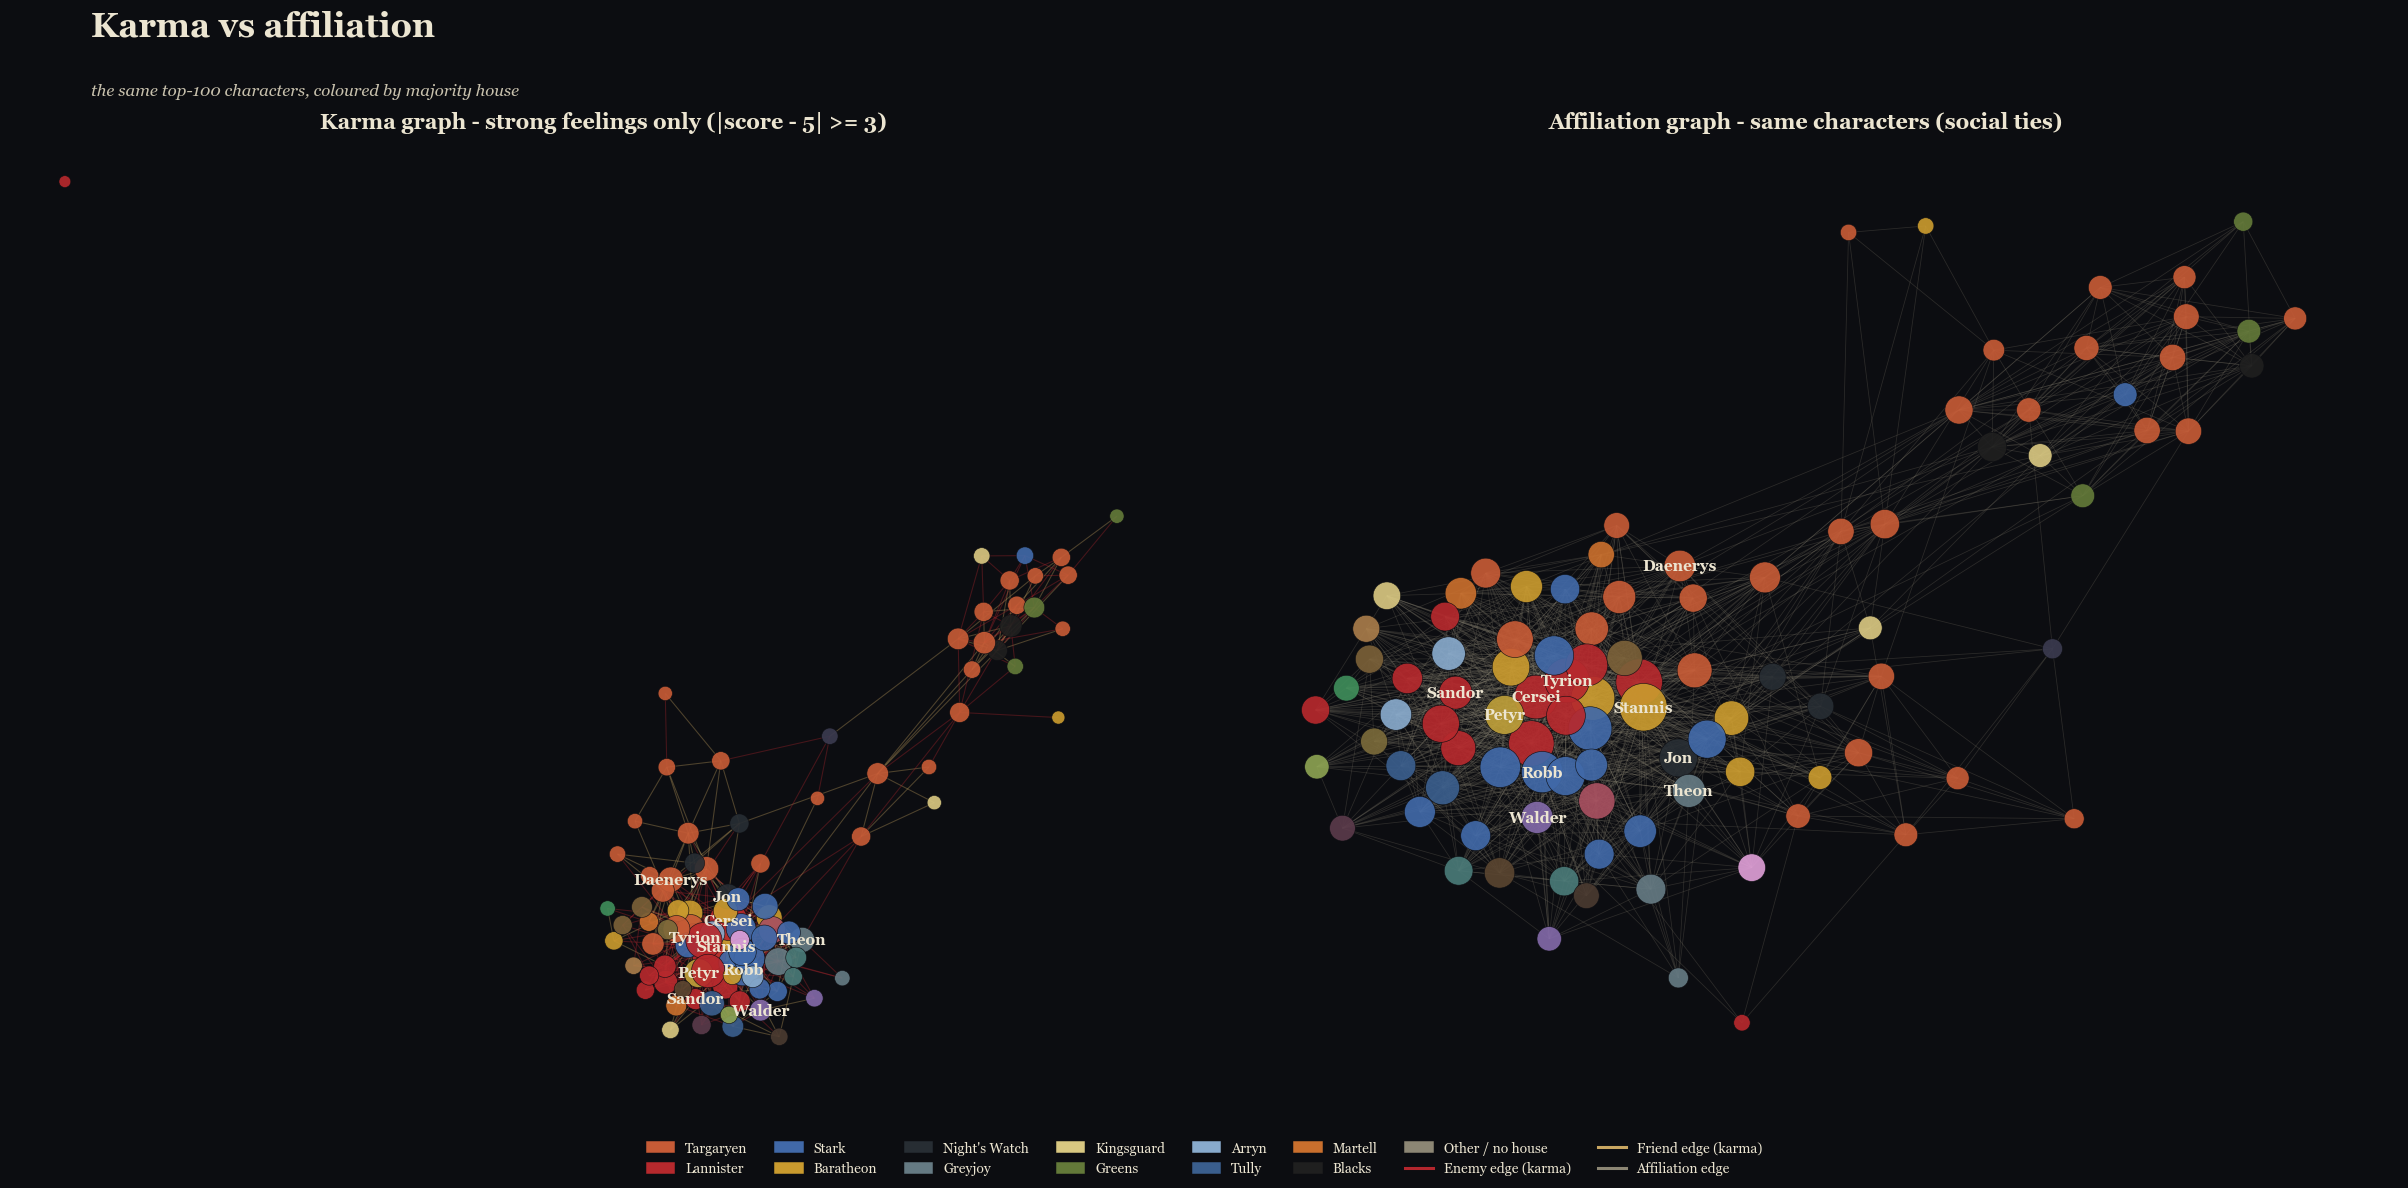

In [36]:
# Karma viz pt 2: same top-100 characters, two edge sets, one majority-house
# palette. GOT-themed; nodes keep the website house palette here.
PT2_THRESHOLD = 3  # |score - 5| >= 3 counts as a strong feeling

BARATHEON_VARIANTS = {
    'House_Baratheon_of_Dragonstone':     'House_Baratheon',
    "House_Baratheon_of_King's_Landing":  'House_Baratheon',
}

def _norm_alleg(s):
    seen, out = set(), []
    for q in s.split(';'):
        q = BARATHEON_VARIANTS.get(q.strip(), q.strip())
        if q and q not in seen:
            seen.add(q)
            out.append(q)
    return out

alleg_lists = {row['ID']: _norm_alleg(row['allegiance']) for _, row in df.iterrows()}
global_counts = Counter()
for lst in alleg_lists.values():
    global_counts.update(lst)

def majority_house(cid):
    lst = alleg_lists.get(cid, [])
    if not lst:
        return ''
    return max(lst, key=lambda h: global_counts[h])

top100 = pd.read_csv(BASE_DIR / 'csvs' / 'top100_outgoing_v3.csv')
nodes = [i for i in top100['ID'] if i in DG]
nodeset = set(nodes)
maj = {n: majority_house(n) for n in nodes}
ncolor = {n: to_rgba(house_color_for(maj[n])) for n in nodes}

KA = nx.Graph()
KA.add_nodes_from(nodes)
for u, v, d in DG.edges(data=True):
    if u in nodeset and v in nodeset and abs(d['score'] - 5) >= PT2_THRESHOLD:
        KA.add_edge(u, v, score=d['score'])

AF = nx.Graph()
AF.add_nodes_from(nodes)
for _, row in df.iterrows():
    s = row['ID']
    if s not in nodeset or not row['affiliated']:
        continue
    for t in (x.strip() for x in row['affiliated'].split(';')):
        if t in nodeset and t != s:
            AF.add_edge(s, t)

FEATURED = ['Jon_Snow', 'Cersei_Lannister', 'Daenerys_Targaryen',
            'Tyrion_Lannister', 'Petyr_Baelish', 'Theon_Greyjoy',
            'Walder_Frey', 'Stannis_Baratheon', 'Robb_Stark',
            'Sandor_Clegane']

pos_a = nx.spring_layout(KA, k=0.35, seed=42, iterations=200)
pos_b = nx.spring_layout(AF, k=0.30, seed=42, iterations=200)

fig, axes = plt.subplots(1, 2, figsize=(22, 11))

def _panel(ax, Gp, posp, title, edge_kw):
    nx.draw_networkx_edges(Gp, posp, ax=ax, **edge_kw)
    ax.scatter([posp[n][0] for n in nodes], [posp[n][1] for n in nodes],
               c=[ncolor[n] for n in nodes],
               s=[60 + Gp.degree(n) * 14 for n in nodes],
               alpha=0.92, linewidths=0.4, edgecolors=GOT_BG, zorder=3)
    for n in FEATURED:
        if n in posp:
            ax.annotate(name_by_id.get(n, n).split()[0], posp[n], fontsize=10,
                        fontweight='bold', color=GOT_INK,
                        ha='center', va='center', zorder=4)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

karma_edge_colors = [GOT_CRIMSON if d['score'] <= 5 - PT2_THRESHOLD else GOT_GOLD
                     for _, _, d in KA.edges(data=True)]
_panel(axes[0], KA, pos_a,
       f'Karma graph - strong feelings only (|score - 5| >= {PT2_THRESHOLD})',
       dict(edge_color=karma_edge_colors, alpha=0.35, width=0.7, arrows=False))
_panel(axes[1], AF, pos_b,
       'Affiliation graph - same characters (social ties)',
       dict(edge_color=GOT_MUTED, alpha=0.25, width=0.5))

present_houses = [h for h, _ in Counter(h for h in maj.values() if h).most_common(12)]
handles = [mpatches.Patch(color=house_color_for(h),
                          label=h.replace('House_', '').replace('_', ' '))
           for h in present_houses]
handles += [
    mpatches.Patch(color=PALETTE['muted'], label='Other / no house'),
    plt.Line2D([0], [0], color=GOT_CRIMSON, lw=2, label='Enemy edge (karma)'),
    plt.Line2D([0], [0], color=GOT_GOLD,    lw=2, label='Friend edge (karma)'),
    plt.Line2D([0], [0], color=GOT_MUTED,   lw=2, label='Affiliation edge'),
]
fig.legend(handles=handles, loc='lower center', ncol=8, fontsize=9)
got_title(fig, 'Karma vs affiliation',
          'the same top-100 characters, coloured by majority house')
plt.tight_layout(rect=[0, 0.05, 1, 0.90])
save_fig(fig, KARMA_FIG_DIR / 'karma_vs_affiliation.png')
plt.show()


## Grouped by affiliation

Instead of a force layout, nodes are now **clustered into house wedges around a
ring** (largest houses first). Position therefore encodes *only* affiliation, so
every karma edge that crosses the ring is a cross-house feeling, and red chords
between two wedges are open conflict between houses.

Two versions:

* **Internal only** — just the 100 characters, with karma edges *among
  themselves*. This isolates the conflicts the major players have with each
  other, with no peripheral targets.
* **All targets** — the same 100 sources, but every outgoing karma edge they
  have, including targets outside the top 100 (grouped by the target's own
  house). This shows how the major players feel about the wider cast.

Only non-neutral edges (enemy `≤ 3` / friend `≥ 7`, the website thresholds) are
drawn, so the picture is feelings, not acquaintance.

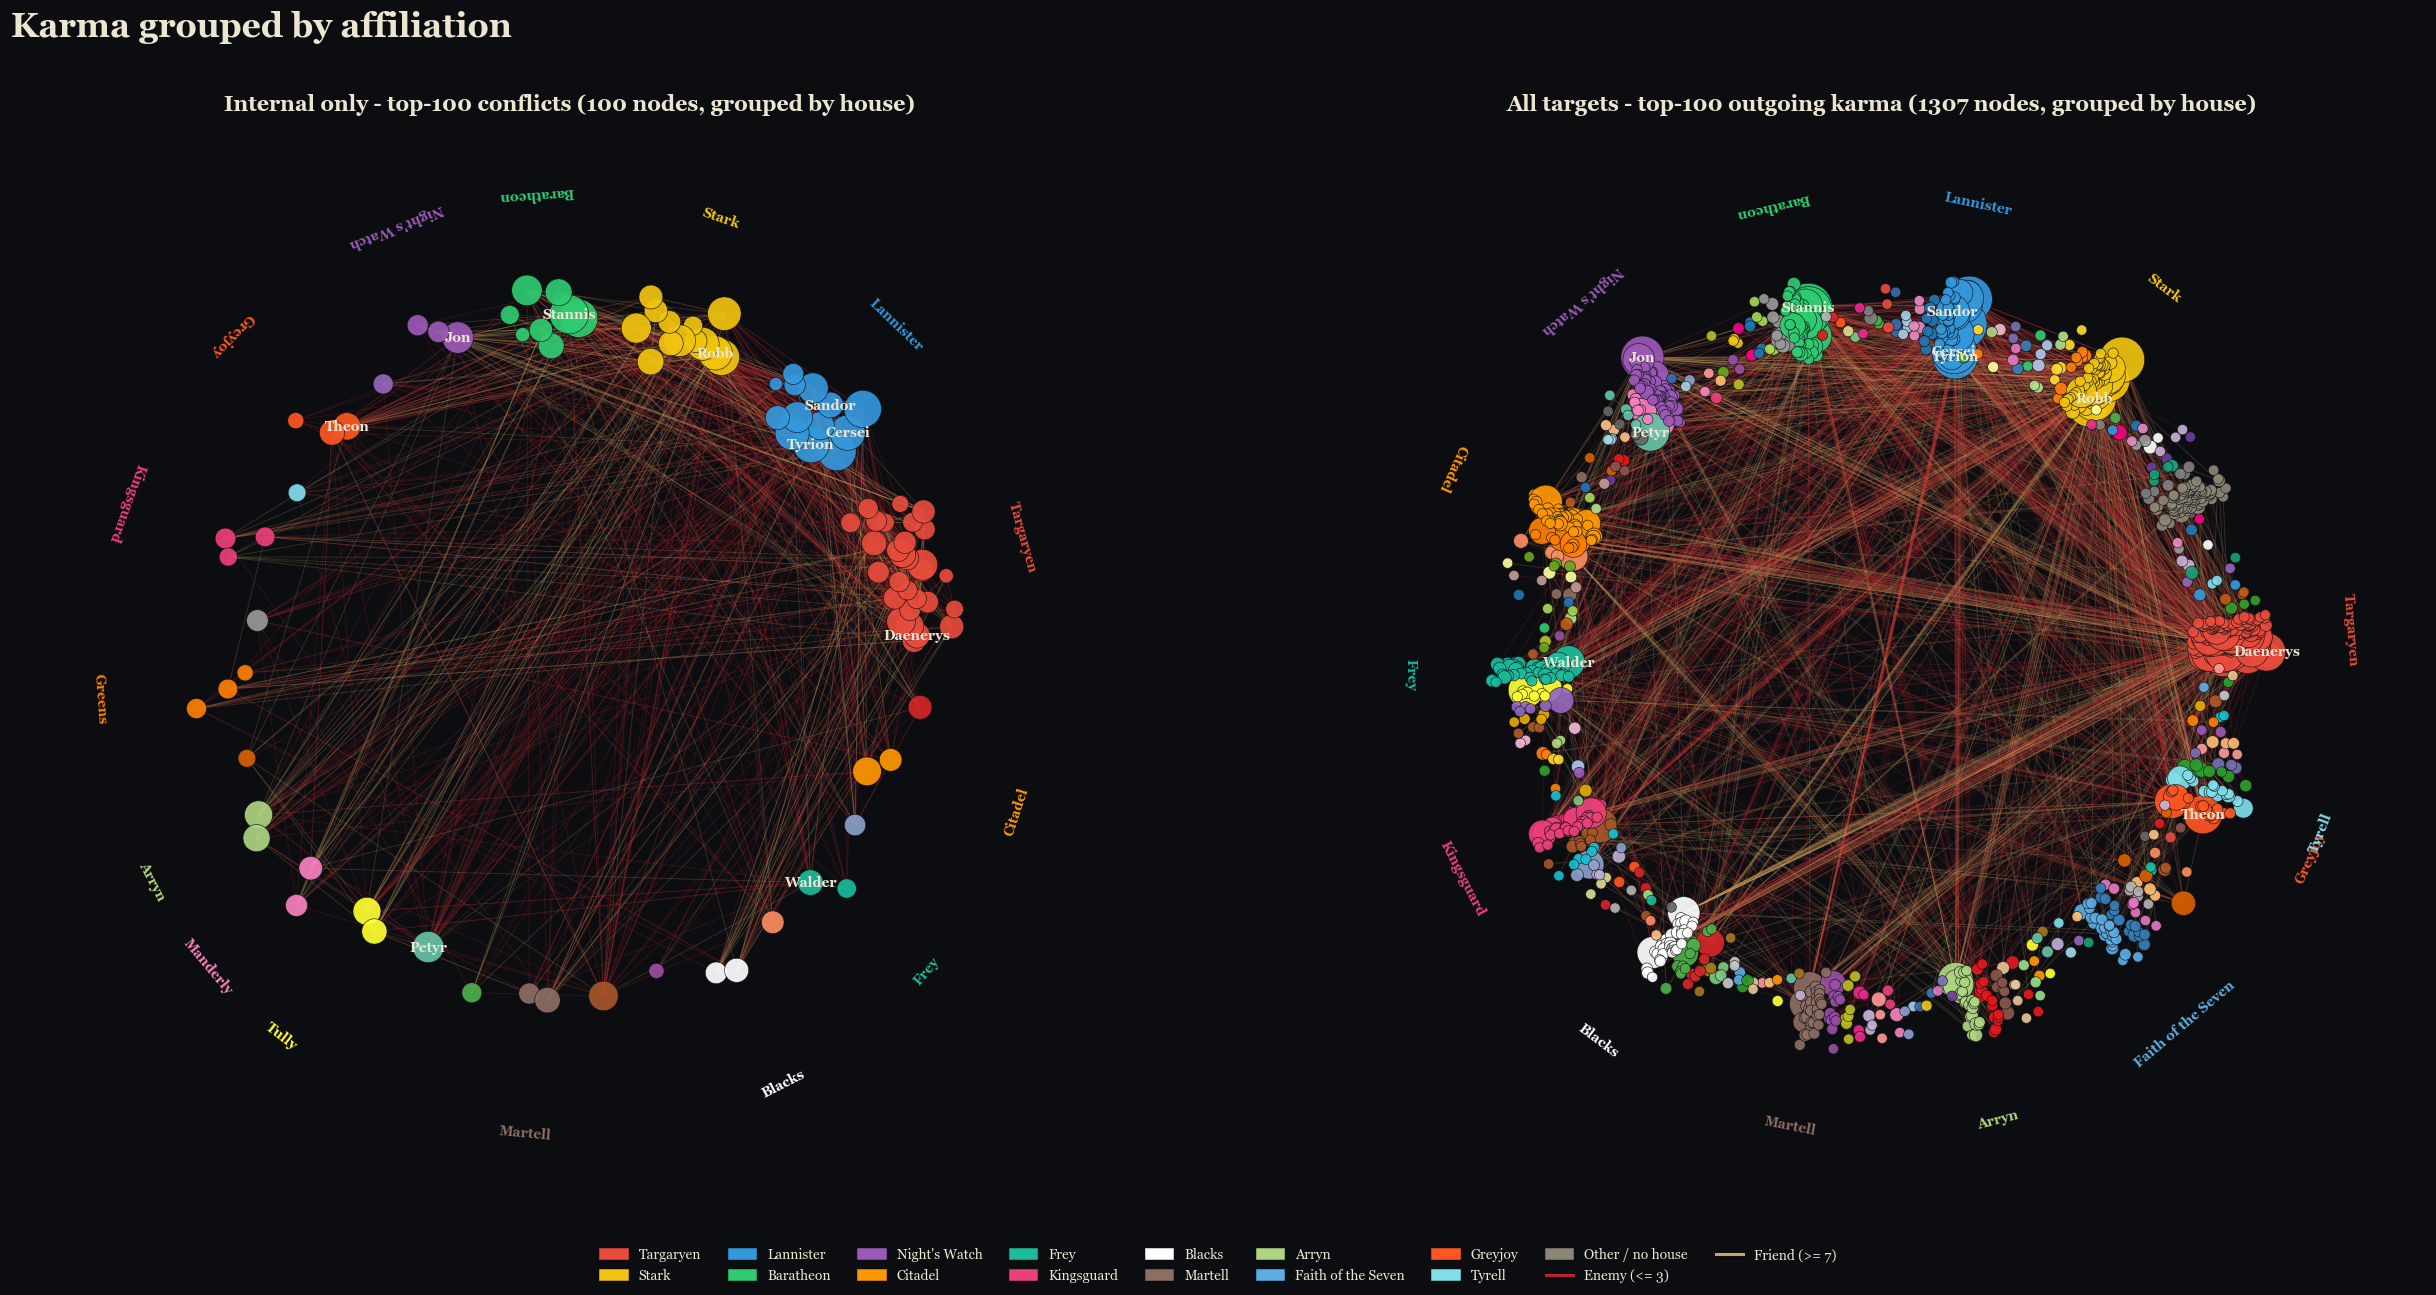

In [37]:
from collections import defaultdict

EDGE_LO, EDGE_HI = 3, 7  # website getScoreColor thresholds

# Majority house for every node that can appear (top-100 + all their targets)
house_all = {n: majority_house(n) for n in DG.nodes()}

def grouped_layout(G, house_of, radius=1.0, total_gap_frac=0.30,
                   pad_frac=0.22, jitter=0.12, n_buckets=14, seed=42):
    """Per-house wedges around a ring. Two tricks keep the web readable:
    (1) wedge width uses sqrt(size) so one mega-house can't hog the ring;
    (2) houses are dealt into n_buckets with a largest-processing-time
        heuristic, so the biggest houses land in different buckets and end
        up roughly evenly spaced around the circle instead of all adjacent."""
    rng = np.random.default_rng(seed)
    groups = defaultdict(list)
    for n in G.nodes():
        groups[house_of.get(n, '') or '(no house)'].append(n)
    by_size = sorted(groups, key=lambda h: -len(groups[h]))

    B = max(2, min(n_buckets, len(by_size)))
    buckets = [[] for _ in range(B)]
    load = [0.0] * B
    for h in by_size:
        j = min(range(B), key=lambda b: load[b])
        buckets[j].append(h)
        load[j] += len(groups[h]) ** 0.5
    houses = [h for bucket in buckets for h in bucket]

    weight = {h: len(groups[h]) ** 0.5 for h in houses}
    tot_w = sum(weight.values())
    gap = (2 * np.pi * total_gap_frac) / len(houses)
    span = 2 * np.pi - len(houses) * gap
    pos, centroid, sizes = {}, {}, {}
    cur = 0.0
    for h in houses:
        members = groups[h]
        sizes[h] = len(members)
        seg = span * (weight[h] / tot_w)
        inner = seg * (1 - pad_frac)
        start = cur + (seg - inner) / 2
        for k, v in enumerate(members):
            frac = (k + 0.5) / len(members) if len(members) > 1 else 0.5
            theta = start + inner * frac
            r = radius + ((k % 3) - 1) * 0.05 + (rng.random() - 0.5) * jitter
            pos[v] = (r * np.cos(theta), r * np.sin(theta))
        centroid[h] = cur + seg / 2
        cur += seg + gap
    return pos, houses, centroid, sizes

# Internal: karma edges among the top-100 only
KI = nx.DiGraph()
KI.add_nodes_from(nodes)
for u, v, d in DG.edges(data=True):
    if u in nodeset and v in nodeset:
        KI.add_edge(u, v, score=d['score'])

# All: every outgoing edge from the top-100 (targets included, any house)
KALL = nx.DiGraph()
for u, v, d in DG.edges(data=True):
    if u in nodeset:
        KALL.add_edge(u, v, score=d['score'])

# DISTINCT house palette (kept distinct on purpose, not the muted GOT palette),
# ranked by combined size so a house keeps one colour across both panels.
_combined = Counter()
for n in KI.nodes():
    if maj.get(n):
        _combined[maj[n]] += 1
for n in KALL.nodes():
    if house_all.get(n):
        _combined[house_all[n]] += 1
_ranked = [h for h, _ in _combined.most_common()]
HCOLOR = {h: DISTINCT_PALETTE[i % len(DISTINCT_PALETTE)]
          for i, h in enumerate(_ranked)}

def dcolor(h):
    return HCOLOR.get(h, to_rgba(GOT_MUTED)) if h else to_rgba(GOT_MUTED)

def draw_grouped(ax, G, house_of, title, label_min):
    pos, houses, centroid, sizes = grouped_layout(G, house_of)
    drawn = [(u, v, d) for u, v, d in G.edges(data=True)
             if d['score'] <= EDGE_LO or d['score'] >= EDGE_HI]
    ec = [GOT_CRIMSON if d['score'] <= EDGE_LO else GOT_GOLD
          for _, _, d in drawn]
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v, _ in drawn],
                           edge_color=ec, alpha=0.22, width=0.6,
                           arrows=False, ax=ax)
    ax.scatter([pos[n][0] for n in G.nodes()], [pos[n][1] for n in G.nodes()],
               c=[dcolor(house_of.get(n, '')) for n in G.nodes()],
               s=[40 + G.degree(n) * 6 for n in G.nodes()],
               alpha=0.92, linewidths=0.4, edgecolors=GOT_BG, zorder=3)
    for h in houses:
        if sizes[h] < label_min or h == '(no house)':
            continue
        a = centroid[h]
        ax.text(1.34 * np.cos(a), 1.34 * np.sin(a),
                h.replace('House_', '').replace('_', ' '),
                fontsize=9, ha='center', va='center',
                rotation=np.degrees(a) - 90 if -np.pi/2 < a < np.pi/2
                else np.degrees(a) + 90,
                color=dcolor(h), fontweight='bold', zorder=5)
    for n in FEATURED:
        if n in pos:
            ax.annotate(name_by_id.get(n, n).split()[0], pos[n], fontsize=9,
                        fontweight='bold', color=GOT_INK,
                        ha='center', va='center', zorder=6)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-1.55, 1.55); ax.set_ylim(-1.55, 1.55)
    ax.set_aspect('equal'); ax.set_axis_off()

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
draw_grouped(axes[0], KI, maj,
             f'Internal only - top-100 conflicts ({KI.number_of_nodes()} nodes, '
             f'grouped by house)', label_min=2)
draw_grouped(axes[1], KALL, house_all,
             f'All targets - top-100 outgoing karma ({KALL.number_of_nodes()} '
             f'nodes, grouped by house)', label_min=18)

present = [h for h, _ in _combined.most_common(14)]
handles = [mpatches.Patch(color=dcolor(h),
                          label=h.replace('House_', '').replace('_', ' '))
           for h in present]
handles += [
    mpatches.Patch(color=GOT_MUTED, label='Other / no house'),
    plt.Line2D([0], [0], color=GOT_CRIMSON, lw=2, label=f'Enemy (<= {EDGE_LO})'),
    plt.Line2D([0], [0], color=GOT_GOLD,    lw=2, label=f'Friend (>= {EDGE_HI})'),
]
fig.legend(handles=handles, loc='lower center', ncol=9, fontsize=9)
got_title(fig, 'Karma grouped by affiliation',
          '')
plt.tight_layout(rect=[0, 0.05, 1, 0.90])
save_fig(fig, KARMA_FIG_DIR / 'karma_grouped_by_affiliation.png')
plt.show()


**Reading these.** Because position is now *only* house, a wedge that is mostly internal green is a house at peace with itself; one shot through with red chords to other wedges is a house defined by its rivalries. The **internal-only** panel strips away peripheral targets so the major players' mutual hostility stands alone; the **all-targets** panel shows the same characters' feelings radiating out across the wider cast.

## Per-house karma scores

For each house, three averages over the karma a house's members *give out*
(karma is only scored from the top-100, so these are the major players' feelings
grouped by their majority house):

* **avg outgoing** - mean score of every edge leaving the house (1 = sworn
  enemy ... 10 = closest bond).
* **avg internal** - edges whose target is the *same* house (how a house feels
  about its own).
* **avg external** - edges whose target is a *different* house (how a house
  feels about everyone else).

A house that is warm internally but cold externally is a tight in-group; one
that is cold both ways is simply belligerent.

,house,n_out,avg_outgoing,n_internal,avg_internal,n_external,avg_external
0,Targaryen,1475,5.01,629,5.59,846,4.59
1,Lannister,791,4.31,178,4.97,613,4.12
2,Stark,732,5.29,160,7.48,572,4.68
3,Baratheon,487,4.82,107,5.29,380,4.69
4,Night's Watch,183,5.77,68,5.65,115,5.83
5,Greyjoy,170,4.61,34,3.65,136,4.85
6,Kingsguard,123,5.50,17,5.88,106,5.44
7,Martell,109,4.97,34,6.38,75,4.33
8,Greens,109,4.82,7,5.71,102,4.75
9,Blacks,103,5.60,13,5.00,90,5.69


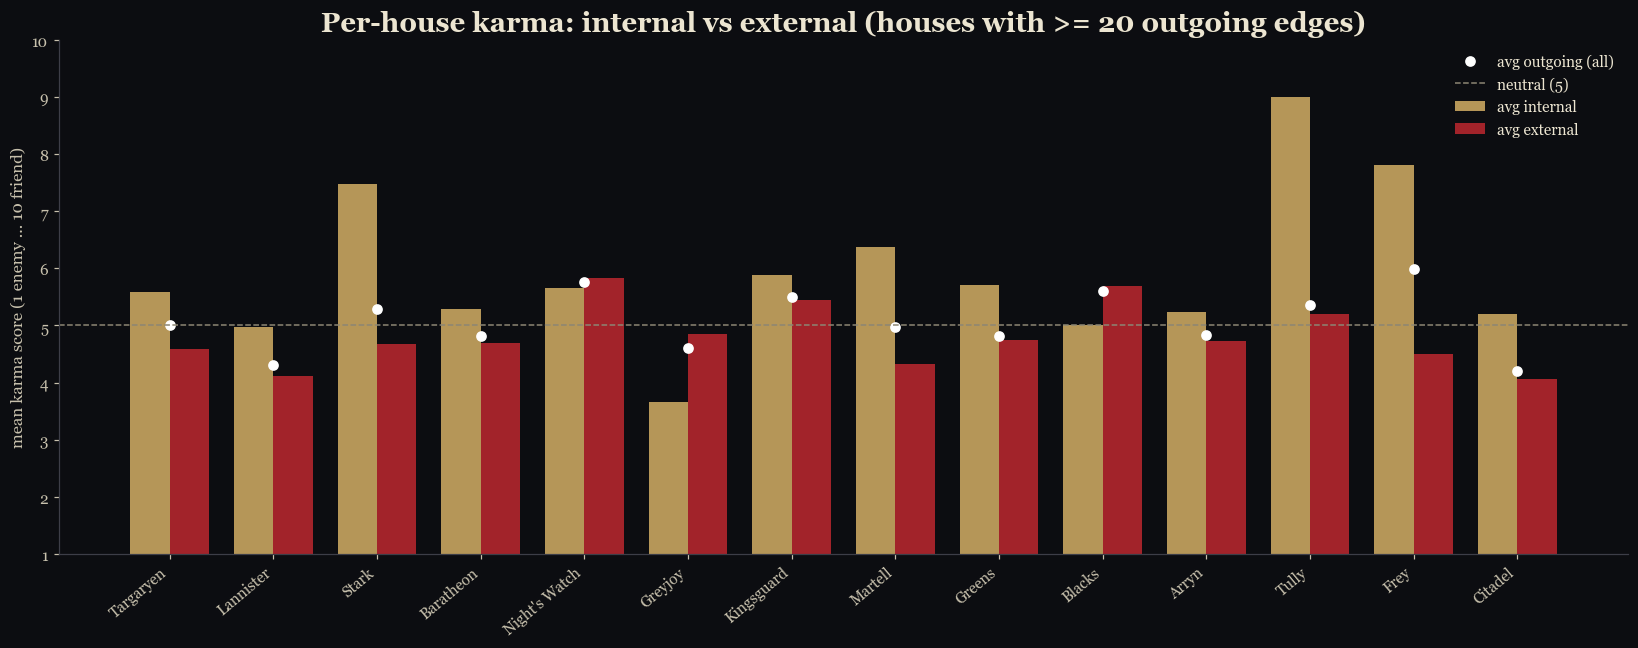

In [38]:
# Per-house average outgoing / internal / external karma. Source house =
# majority house of the (top-100) source; same mapping the grouped views use.
rows = []
for h in set(house_all.values()):
    if not h:
        continue
    out, internal, external = [], [], []
    for u, v, d in DG.edges(data=True):
        if house_all.get(u) != h:
            continue
        s = d['score']
        out.append(s)
        (internal if house_all.get(v) == h else external).append(s)
    if not out:
        continue
    rows.append({
        'house':        h.replace('House_', '').replace('_', ' '),
        'n_out':        len(out),
        'avg_outgoing': round(np.mean(out), 2),
        'n_internal':   len(internal),
        'avg_internal': round(np.mean(internal), 2) if internal else np.nan,
        'n_external':   len(external),
        'avg_external': round(np.mean(external), 2) if external else np.nan,
    })

house_scores = (pd.DataFrame(rows)
                  .sort_values('n_out', ascending=False)
                  .reset_index(drop=True))
display(house_scores.head(25))

MIN_OUT = 20
top = house_scores[house_scores['n_out'] >= MIN_OUT].head(14)
x = np.arange(len(top))
w = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - w/2, top['avg_internal'], w, label='avg internal',
       color=GOT_GOLD, alpha=0.9)
ax.bar(x + w/2, top['avg_external'], w, label='avg external',
       color=GOT_CRIMSON, alpha=0.9)
ax.plot(x, top['avg_outgoing'], 'o', color='w', lw=1.5,
        ms=6, label='avg outgoing (all)')
ax.axhline(5, color=GOT_MUTED, ls='--', lw=1, label='neutral (5)')
ax.set_xticks(x)
ax.set_xticklabels(top['house'], rotation=40, ha='right')
ax.set_ylabel('mean karma score (1 enemy ... 10 friend)')
ax.set_ylim(1, 10)
ax.set_title(f'Per-house karma: internal vs external '
             f'(houses with >= {MIN_OUT} outgoing edges)')
ax.legend(loc='upper right')
plt.tight_layout()
save_fig(fig, KARMA_FIG_DIR / 'karma_per_house_scores.png')
plt.show()


**Reading it.** Almost every house sits *below* the neutral line: even toward their own, the major players are wary. The internal-minus-external gap is the in-group bonus: where the green bar clears the red one, a house treats its own markedly better than outsiders (kin-loyal houses like the Starks/Freys); where the two are level and low, the house is hostile across the board, the engine of the saga's conflict.

**Reading the two panels.** The node set is identical, the top-100 most-connected characters. Only the edges and the layout change. Where a house stays a single colour-blob in both panels (the tightly-knit Freys), feeling and affiliation agree. Where a house is one blob on the right but scattered with red on the left, formally-allied characters still hold each other in contempt: the karma layer surfaces conflict *within* allegiances that the affiliation graph alone cannot see.